In [1]:
#esercizio 1

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import pascal

n=5
A=pascal(n)

#CNS esistenza e unicità fatt LU: se A appartenente a RnxRn è non singolare
#la fatt LU  esiste ed è unica se e solo se le sottomatrici principali di A sono
#non singolari
possible=True
if np.linalg.det(A)<=0:
    possible=False

for i in range(n):
    det_i=np.linalg.det(A[:i,:i])
    if (det_i<=0):
        possible=False

if(possible==False):
    print("CNS non soddisfatta")
else:
    print("CNS soddisfatta")


CNS soddisfatta


In [6]:
def fwsub(A,b):
  """
  Algoritmo di sostituzione in avanti - forward substitution
  Input:
  A: matrice quadrata triangolare inferiore
  b: termine noto
  Output:
  x: soluzione del sistema lineare = b
  """
  # dimesinoe termine noto b
  n = b.shape[0]
  # Verifichiamo che la matrice sia quadrata
  if A.shape[0] != A.shape[1]:
   raise RuntimeError("ERRORE: matrice non quadrata")
  # Verifichiamo che la matrice sia triangolare inferiore
  if (A != np.tril(A)).any():
    raise RuntimeError("ERRORE: matrice non triangolare inferiore")
  # Verifichiamo che la matrice sia invertibile
  # Essendo triangolare, i suoi autovalori si trovano sulla diagonale principale
  if np.prod(np.diag(A)) == 0:
    raise RuntimeError("ERRORE: matrice singolare")

  #inizializzo il vettore
  x = np.zeros(n)
  # costruzione forward substitution
  x[0] = b[0] / A[0, 0]
  for i in range(1, n):
    x[i] = (b[i] - A[i, 0:i] @ x[0:i]) / A[i, i]
   
  return x

In [7]:
def bksub(A,b):
  """
  Algoritmo di sostituzione all'indietro - backward substitution
  Input:
  A: matrice quadrata triangolare superiore
  b: termine noto
  Output:
  x: soluzione del sistema lineare = b
  """
  n = b.shape[0]

  #Verifica matrice quadrata
  if (A.shape[0]!=A.shape[1]):
    raise RuntimeError("ERRORE: matrice non quadrata")
  
  #verifica matrice triangolare superiore
  if (A != np.triu(A)).any():
    raise RuntimeError("ERRORE: matrice non triangolare superiore")
  
  if np.prod(np.diag(A))==0:
    raise RuntimeError ("ERRORE: matrice singolare")

  x=np.zeros(n)
  x[-1] = b[-1] / A[-1, -1]

  for i in range (n-2, -1 , -1): #-1 perché ultimo elemento del range è escluso quindi per andare da n-2 a zero devo scrivere range da n-2 a -1
    # l'ultimo -1 invece serve per far andare il contatore da n-2 a zero (quindi a ogni ciclo sottraggo 1 a i)
    x[i] = (b[i] - A[i, i + 1: n] @ x[i + 1: n]) / A[i, i] # somma da 1 a n-1 nella realtà ma poiché ultimo elemento non viene contato nel ciclo metto fino a n per avere quello che voglio
          
  return x

In [11]:
from scipy.linalg import lu

x_ex=np.ones(n)
b=A@x_ex

P,L,U=lu(A)
if (P==np.eye(n)).all():
    print('no pivoting')
else:
    print('pivoting')

y=fwsub(L, P.T @b)
x=bksub(U, y)
print(x)


pivoting
[1. 1. 1. 1. 1.]


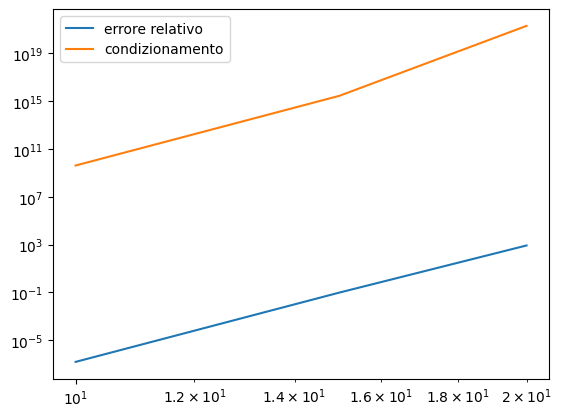

In [17]:
N=np.array([10,15,20])
err_rel=[]
cond=[]
for n in N:
    A=pascal(n)
    x_ex=np.ones(n)
    b=A@x_ex

    P,L,U=lu(A)

    y=fwsub(L, P.T @b)
    x=bksub(U, y)

    err_rel.append(np.linalg.norm(x-x_ex)/np.linalg.norm(x_ex))
    cond.append(np.linalg.cond(A))

plt.loglog(N, err_rel, label='errore relativo')
plt.loglog(N, cond, label='condizionamento')
plt.legend()



In [18]:
#esercizio 2

In [20]:
#pm: I=(b-a)*f(m)
#pmC: I= H/2*somma per i da 1 a n+1 di f((xi-1+xi)/2)
#errpmc=(b-a)/24*H^2*max|f''(x)|
#ordine di accuratezza 2 e grado esattezza 1

#simpson: I=(b-a)/6*(f(a)+4*f(m)+f(b))
#simpson comp: I=H/6*somma per i da 1 a n+1 di: (f(xi-1)+f((xi-1+xi)/2)+f(xi))
#err=(b-a)*H^4/16/180*max|fiv(x)|
#ordine accuratezza: 4, grado di esattezza 3


In [21]:
def pmedcomp(f, a, b, N):
  """
  Formula del punto medio composita
  Input:
     f:   funzione da integrare
     a:   estremo sinistro dell'intervallo di integrazione
     b:   estremo destro dell'intervallo di integrazione
     N:   numero di sottointervalli (N = 1 formula di integrazione semplice)
  Output:
     I:   integrale approssimato
  """
  #ampiezza di ciascun sotto-intervallo
  h=(b-a)/N
  #griglia di punti
  x=np.linspace(a,b, N+1)

  #vettore degli estremi sinistri (Left) di ciascun sottointervallo
  xL = x[:-1] #prendo tutti i nodi a partire dal primo (incluso) fino all'ultimo (escluso)
 #vettore degli estremi destri
  xR= x[1:] #prendo tutti i nodi dal primo (escluso) in poi

  #vettore dei èunti medi
  xM= (xL+xR)/2 #sommo i vettori componente per componente (che risultano abbinati per ogni intervallo) e divido per due

  #calcolo integrale
  I = h * f(xM).sum() #.sum applicato a un array calcola la somma di tutte le sue componenti
  
  return I

In [22]:
def simpcomp(f, a, b, N):
  """
  Formula di Cavalieri-Simpson composita
  Input:
     f:   funzione da integrare
     a:   estremo sinistro dell'intervallo di integrazione
     b:   estremo sinistro dell'intervallo di integrazione
     N:   numero di sottointervalli (N = 1 formula di integrazione semplice)
  Output:
     I:   integrale approssimato
  """
  h=(b-a)/N
  x=np.linspace(a, b, N+1)

  #estremi sinistri
  xL=x[:-1]
  #estremi destri
  xR=x[1:]
  #vettore dei punti medi
  xM=(xL+xR)/2
  #calcolo integrale
  I=h/6*(f(xL)+4*f(xM)+f(xR)).sum()
  
  return I

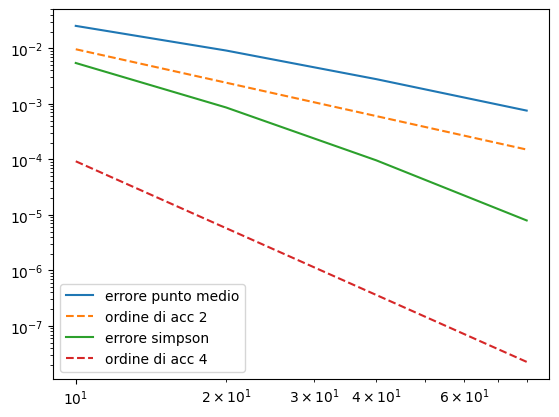

In [35]:
a=1.02
b=2
N=np.array([10,20,40,80])
f=lambda x: 1/np.sqrt(x**2-1)
F=lambda x:np.log(x+np.sqrt(x**2-1))
I_ex=F(b)-F(a)
x_grid=np.linspace(a, b, 1000)
err_pm=[]
err_simp=[]
h=[]
for n in N:
    h.append((b-a)/n)
    Ipm=pmedcomp(f,a,b,n)
    err_pm.append(np.max(np.abs(Ipm - I_ex)))
    
    Isimp=simpcomp(f,a,b,n)
    err_simp.append(np.max(np.abs(Isimp-I_ex)))

h=np.array(h)
plt.loglog(N, err_pm, label='errore punto medio')
plt.loglog(N, h**2,'--', label='ordine di acc 2' )
plt.loglog(N, err_simp, label='errore simpson')
plt.loglog(N, h**4, '--', label='ordine di acc 4')
plt.legend()

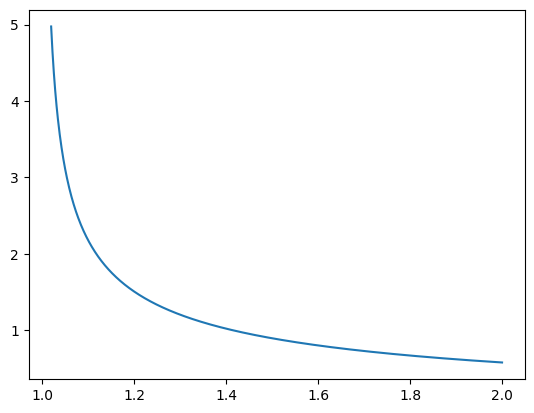

In [36]:
plt.plot(x_grid, f(x_grid))

In [2]:
#u'=2*e^(2x)*x^2+e^(2x)*2x
#u''=4e^(2x)*x^2+4e^(2x)*x+4*e^(2x)*x+2e^(2x)= 
#   =2e^(2x)*(2*x^2+4*x+1)
#f=-2e^(2x)*(2*x^2+4*x+1)

#u(0)=0 u'(1)=2*e^(2)+e^(2)*2=4e^2



In [3]:
from fem_utils import *
from fem_utils_plot import *

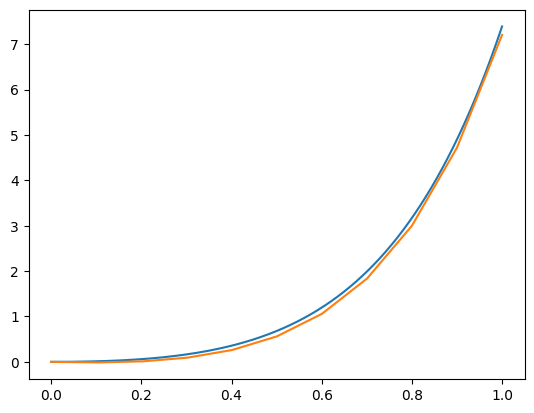

In [7]:
h=1/10
f=lambda x: -2*np.exp(2*x)*(2*x**2+4*x+1)
a=0
b=1
N=int((b-a)/h)
grid=Grid(a,b,N)
grid.compute_geometry()

f_dofs=fun2dof(grid, f)
A=diffusion(grid)
M=mass(grid)
F=M @ f_dofs
dirichlet_nodes=[0]
dirichlet_values=[0]
bc_values=np.zeros(N+1)
bc_values[dirichlet_nodes]=dirichlet_values
F[-1]+=4*np.exp(2)
keep_dof=np.ones(N+1, dtype=bool)
keep_dof[dirichlet_nodes]=False
R=create_restriction(keep_dof)

A_0=R @ A @ R.T
F_0= R@(F-A@bc_values)

u_0=np.linalg.solve(A_0, F_0)
uh=R.T@ u_0 + bc_values

nodes=grid.nodes
x_grid=np.linspace(a,b, 1000)
u=np.interp(x_grid, nodes, uh)
u_ex=lambda x: np.exp(2*x)*x**2
plt.plot(x_grid, u_ex(x_grid), label='sol esatta')
plt.plot(x_grid, u, label='soluzione FEM')

In [19]:
N=np.array([20,40,80])
err_l2=[]
for n in N:
    h=1/n
    grid=Grid(a,b,n)
    grid.compute_geometry()

    f_dofs=fun2dof(grid, f)
    A=diffusion(grid)
    M=mass(grid)
    F=M @ f_dofs

    dirichlet_nodes=[0]
    dirichlet_values=[0]
    bc_values=np.zeros(n+1)
    bc_values[dirichlet_nodes]=dirichlet_values

    F[-1]+=4*np.exp(2)
    keep_dof=np.ones(n+1, dtype=bool)
    keep_dof[dirichlet_nodes]=False
    R=create_restriction(keep_dof)

    A_0=R @ A @ R.T
    F_0= R@(F-A@bc_values)

    u_0=np.linalg.solve(A_0, F_0)
    uh=R.T@ u_0 + bc_values

    nodes=grid.nodes
    err_l2.append(error_l2(grid, u_ex, uh))
    




TypeError: 'numpy.ndarray' object is not callable